## 解答

#**1. 分析コード**

In [8]:
# ===========================================================================================================================================================
# 分析アプローチ:
#   1) 仮説A/Bは「駅前の横断方向の人流」が主因と考え、設定した帯域のみ観測。
#   2) オプティカルフローで画素移動を推定し、左右方向成分fxを方向別に集計。
#        - fx > +FLOW_THR : A方向（左→右 / 電車由来）
#        - fx < -FLOW_THR : B方向（右→左 / バス由来）
#      方向別fxの総和を「流量指数」として設定したbinで積算し、B/A比で結果を判定する。
#   3) MOG2を使用し、前景の動き（人物）に限定してノイズを抑制する。
#
# 分析手法の選定理由:
#   - yolo等の物体検出AIによる追跡は、人同士の重なり等により、検出が不安定になりやすい。一方、オプティカルフローは群衆の方向性を連続量として得やすいため。
# ===========================================================================================================================================================

In [9]:
# =========================
# 0) googleドライブマウント
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:

# =========================
# 1) ライブラリインストール
# =========================
!pip -q install tqdm

In [11]:
# =========================
# 2) Imports
# =========================
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [12]:
# =========================
# 3) 設定
# =========================
VIDEO_PATH = "/content/drive/MyDrive/kyoto_statation.mp4"   # 解析動画パス
OUT_DIR = "/content/drive/MyDrive/"                         # 分析結果出力パス
os.makedirs(OUT_DIR, exist_ok=True)

BIN_SEC = 10        # 集計時間幅（秒）
MIN_FLOW_MAGNITUDE = 0.2    # 画素が動いたと判定する閾値

# 背景差分処理（MOG2）パラメータ
MOG2_HISTORY = 200
MOG2_VARTHRESH = 16
MOG2_LR = 0.005

HEAT_ALPHA = 0.45         # ヒートマップ透明度
MIN_CLUSTER_PIX = 250     # 小さい画素のクラスタをノイズとみなす閾値

CENTER_LINE = 0.30      # 人が横断する量を観測する中心線の位置
ZONE_HALF_W = 90        # 中心線からの解析範囲（半径）
Y_LINE_RATIO = 0.50     # Y方向の観測設定
OBSERVE_BELOW = True    # True: ラインより下側のみ観測

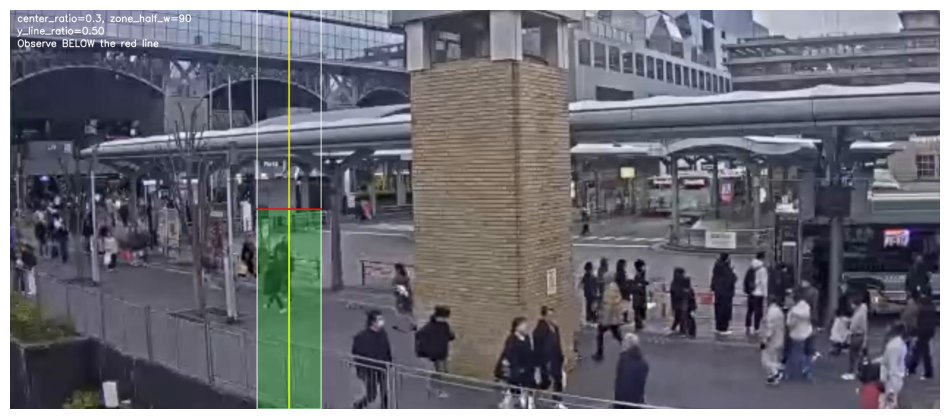

In [13]:
# =============================
# 4) 観測範囲を確認
# =============================
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"動画が開けません: {VIDEO_PATH}")

ret, frame = cap.read()
cap.release()
assert ret, "最初のフレームが読めません。"

H, W = frame.shape[:2]

# 観測する中心線と帯域のX座標を計算する
crossing_line_x = int(W * CENTER_LINE)
zone_left = max(0, crossing_line_x - ZONE_HALF_W)
zone_right = min(W, crossing_line_x + ZONE_HALF_W)

y_line = int(H * Y_LINE_RATIO)

preview = frame.copy()
overlay = preview.copy()

# X方向の帯域
cv2.line(preview, (crossing_line_x, 0), (crossing_line_x, H), (0, 255, 255), 3)
cv2.rectangle(preview, (zone_left, 0), (zone_right, H), (255, 255, 255), 2)

# 帯域内だけYライン
cv2.line(preview, (zone_left, y_line), (zone_right, y_line), (0, 0, 255), 3)

# 下側のみ観測範囲を塗る
if OBSERVE_BELOW:
    cv2.rectangle(overlay, (zone_left, y_line), (zone_right, H), (0, 255, 0), -1)
    label = "Observe BELOW the red line"
else:
    cv2.rectangle(overlay, (zone_left, 0), (zone_right, y_line), (0, 255, 0), -1)
    label = "Observe ABOVE the red line"

preview = cv2.addWeighted(overlay, 0.20, preview, 0.80, 0)

cv2.putText(preview, f"center_ratio={CENTER_LINE}, zone_half_w={ZONE_HALF_W}", (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)
cv2.putText(preview, f"y_line_ratio={Y_LINE_RATIO:.2f}", (20, 70),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)
cv2.putText(preview, label, (20, 105),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [14]:
# ============================================================
# 5) 解析開始
# - 解析結果がパラメータに依存していないことを確認するため、
#   複数のパラメータを組み合わせて解析
# - 各パラメータごとに動画、CSVファイルを保存
# ============================================================

# 解析結果保存先
SWEEP_VIDEO_DIR = os.path.join(OUT_DIR, "videos")
SWEEP_CSV_DIR = os.path.join(OUT_DIR, "result_csv")
os.makedirs(SWEEP_VIDEO_DIR, exist_ok=True)
os.makedirs(SWEEP_CSV_DIR, exist_ok=True)

# 仮説A / Bのどちらが成り立つかを動画左上に表示
def result_text(A, B, eps_ratio=0.10):
    if A <= 0 and B <= 0:
        return "No Significant Movement"
    r = B / (A + 1e-9)
    if r > (1.0 + eps_ratio):
        return "Result: B (bus congestion)"
    elif r < (1.0 - eps_ratio):
        return "Result: A (Train-related congestion)"
    else:
        return "Result: Mixed contribution from trains and buses"

# A / B方向の流れ可視化（矢印）
def draw_arrow_from_mask(
    mask,         # A方向またはB方向と判定された画素のマスク
    fx,           # x方向のオプティカルフロー成分
    vis,          # 描画先の画像
    zone_left,    # ROIを元画像座標へ戻すためのオフセット
    y1,           # ROIの上端のy座標
    color,        # 矢印の色
    direction,    # +1 なら右向き、-1 なら左向き
    flow_thr      # フロー閾値
):
    # ノイズ的な小クラスタを無視するためのフィルタ
    if np.sum(mask) < MIN_CLUSTER_PIX:
      return

    # 矢印描画の重心位置
    ys, xs = np.where(mask)
    cy = int(np.mean(ys))
    cx = int(np.mean(xs))

    # ROI座標から元画像座標へ戻す
    x = zone_left + cx
    y = y1 + cy

    local_fx = float(np.mean(fx[mask])) if np.any(mask) else (direction * flow_thr)
    length = int(np.clip(abs(local_fx) * 20, 20, 80))
    x2 = x + direction * length
    cv2.arrowedLine(vis, (x, y), (x2, y), color, 4, tipLength=0.35)

# 指定した1つのパラメータ設定で動画全体を解析
def run_one_setting(
    center_ratio,                 # 横断流を観測する中心線の位置比率
    zone_half_w,                  # 中心線の左右どれだけを観測帯域にするか
    flow_thr,                     # 流れとみなす最小フロー量
    use_mog2,                     # 背景差分で前景制限するかどうか
    frame_stride,                 # 何フレームおきに処理するか
    y_line_ratio=Y_LINE_RATIO,    # Y方向の境界線位置
    observe_below=OBSERVE_BELOW,  # 赤線より下を観測するかどうか
):
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
      raise FileNotFoundError(f"動画が開けません: {VIDEO_PATH}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    crossing_line_x = int(W * center_ratio)
    zone_left = max(0, crossing_line_x - zone_half_w)
    zone_right = min(W, crossing_line_x + zone_half_w)

    # Y方向の観測範囲
    y_line = int(H * y_line_ratio)
    if observe_below:
        y1, y2 = y_line, H
    else:
        y1, y2 = 0, y_line

    # 出力ファイル名
    tag = f"cr={center_ratio:.2f}_hw={zone_half_w}_thr={flow_thr:.1f}_mog2={use_mog2}_stride={frame_stride}"
    out_video = os.path.join(SWEEP_VIDEO_DIR, f"{tag}.mp4")
    out_csv = os.path.join(SWEEP_CSV_DIR, f"{tag}.csv")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_video, fourcc, fps / frame_stride, (W, H))

    # MOG2初期化
    mog2 = None
    if use_mog2:
        mog2 = cv2.createBackgroundSubtractorMOG2(
            history=MOG2_HISTORY, varThreshold=MOG2_VARTHRESH, detectShadows=False
        )

    # 集計変数
    previous_frame = None   # 前フレームのグレースケール画像
    current_bin = None      # 現在処理中のbin
    bin_A = 0.0             # 現bin内のA流量累積値
    bin_B = 0.0             # 現bin内のB流量累積値
    bin_rows = []           # binごとの結果を保存するリスト

    # 1フレームごとに処理
    frame_idx = -1    # 現在のフレーム番号
    pbar = tqdm(total=nframes, desc=f"run {tag}", leave=False)    # 処理の進捗


    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        pbar.update(1)

        if frame_idx % frame_stride != 0:
            continue

        # グレースケール化
        t = frame_idx / fps
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 現在処理中のフレームがどのbinに属するか決める
        now_bin = int(t // BIN_SEC) * BIN_SEC
        if current_bin is None:
            current_bin = now_bin

        if now_bin != current_bin:
            bin_rows.append([
                current_bin,
                bin_A,
                bin_B,
                bin_B / (bin_A + 1e-9),
                result_text(bin_A, bin_B)
            ])
            current_bin = now_bin
            bin_A = 0.0
            bin_B = 0.0

        if previous_frame is None:
            previous_frame = gray
            continue

        # 観測範囲切り出し
        prev_zone = previous_frame[y1:y2, zone_left:zone_right]
        curr_zone = gray[y1:y2, zone_left:zone_right]

        # オプティカルフロー計算
        flow = cv2.calcOpticalFlowFarneback(
            prev_zone, curr_zone, None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        fx = flow[..., 0]
        fy = flow[..., 1]
        mag = np.sqrt(fx*fx + fy*fy)

        # MOG2と有効画素判定
        if use_mog2:
            fg = mog2.apply(frame, learningRate=MOG2_LR)
            fg_zone = fg[y1:y2, zone_left:zone_right]
            fg_zone = cv2.medianBlur(fg_zone, 5)
            valid = (fg_zone > 0) & (mag > 0.2)
        else:
            valid = (mag > MIN_FLOW_MAGNITUDE)

        A_flow_mask = (fx > +flow_thr) & valid
        B_flow_mask = (fx < -flow_thr) & valid

        # 流量指数を計算
        A_flow = float(np.sum(fx[A_flow_mask])) if np.any(A_flow_mask) else 0.0
        B_flow = float(np.sum(-fx[B_flow_mask])) if np.any(B_flow_mask) else 0.0
        bin_A += A_flow
        bin_B += B_flow

        # フローのヒートマップ可視化
        vis = frame.copy()

        fx_clip = np.clip(fx, -3.0, 3.0)
        fx_norm = (fx_clip + 3.0) / 6.0
        fx_u8 = (fx_norm * 255).astype(np.uint8)
        heat = cv2.applyColorMap(fx_u8, cv2.COLORMAP_JET)

        roi = vis[y1:y2, zone_left:zone_right]
        mix = cv2.addWeighted(roi, 1.0 - HEAT_ALPHA, heat, HEAT_ALPHA, 0)
        vis[y1:y2, zone_left:zone_right] = mix

        # 観測範囲を描く
        cv2.line(vis, (crossing_line_x, 0), (crossing_line_x, H), (0,255,255), 3)
        cv2.rectangle(vis, (zone_left, 0), (zone_right, H), (255,255,255), 1)
        cv2.line(vis, (zone_left, y_line), (zone_right, y_line), (0,0,255), 3)

        # 実際の観測領域を枠で表示
        if observe_below:
            cv2.rectangle(vis, (zone_left, y_line), (zone_right, H), (0,255,0), 2)
        else:
            cv2.rectangle(vis, (zone_left, 0), (zone_right, y_line), (0,255,0), 2)

        # A/B方向の矢印を描く
        draw_arrow_from_mask(A_flow_mask, fx, vis, zone_left, y1, (0,255,0), +1, flow_thr)
        draw_arrow_from_mask(B_flow_mask, fx, vis, zone_left, y1, (0,255,255), -1, flow_thr)

        # 解析状況表示
        w = result_text(bin_A, bin_B)
        cv2.putText(vis, f"{tag}", (20, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)
        cv2.putText(vis, f"10s bin {current_bin:>4d}-{current_bin+BIN_SEC:>4d}s : {w}", (20, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)
        cv2.putText(vis, f"A_flow : {bin_A:.0f}", (20, 105),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,0), 2)
        cv2.putText(vis, f"B_flow : {bin_B:.0f}", (20, 140),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,255), 2)

        writer.write(vis)
        previous_frame = gray

    pbar.close()
    cap.release()
    writer.release()

    # 最終binの保存
    if current_bin is not None:
        bin_rows.append([
            current_bin,
            bin_A,
            bin_B,
            bin_B / (bin_A + 1e-9),
            result_text(bin_A, bin_B)
        ])

    df_bin = pd.DataFrame(
        bin_rows,
        columns=[
            "bin_start_sec",  # bin開始秒
            "A_flow_sum",     # A方向流量指数
            "B_flow_sum",     # B方向流量指数
            "B_over_A",       # B/A比
            "result"          # 仮説判定
            ]
    )
    df_bin.to_csv(out_csv, index=False)

    summary = {
        "center_ratio": center_ratio,
        "zone_half_w": zone_half_w,
        "flow_thr": flow_thr,
        "use_mog2": use_mog2,
        "frame_stride": frame_stride,
        "y_line_ratio": y_line_ratio,
        "observe_below": observe_below,
        "out_video": out_video,
        "out_csv": out_csv,
        "BA_total": df_bin["B_flow_sum"].sum() / (df_bin["A_flow_sum"].sum() + 1e-9),
    }
    return summary

# パラメータ探索
center_ratio_list = [0.30]
zone_half_w_list = [60, 90, 120]
thr_list = [0.8, 1.0, 1.2]
mog2_list = [True, False]
stride_list = [2]

summaries = []
total_jobs = len(center_ratio_list) * len(zone_half_w_list) * len(thr_list) * len(mog2_list) * len(stride_list)

job_pbar = tqdm(total=total_jobs, desc="18 settings")

for center_ratio in center_ratio_list:
    for zone_half_w in zone_half_w_list:
        for flow_thr in thr_list:
            for use_mog2 in mog2_list:
                for frame_stride in stride_list:
                    s = run_one_setting(
                        center_ratio=center_ratio,
                        zone_half_w=zone_half_w,
                        flow_thr=flow_thr,
                        use_mog2=use_mog2,
                        frame_stride=frame_stride,
                        y_line_ratio=Y_LINE_RATIO,
                        observe_below=OBSERVE_BELOW,
                    )
                    summaries.append(s)
                    job_pbar.update(1)

job_pbar.close()

# 全設定のsummaryを保存
df_summary = pd.DataFrame(summaries)
summary_csv = os.path.join(OUT_DIR, "summary.csv")
df_summary.to_csv(summary_csv, index=False)

print("summary saved:", summary_csv)
display(df_summary)

18 settings:   0%|          | 0/18 [00:00<?, ?it/s]

run cr=0.30_hw=60_thr=0.8_mog2=True_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

run cr=0.30_hw=60_thr=0.8_mog2=False_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

run cr=0.30_hw=60_thr=1.0_mog2=True_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

run cr=0.30_hw=60_thr=1.0_mog2=False_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

...

run cr=0.30_hw=120_thr=1.0_mog2=False_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

run cr=0.30_hw=120_thr=1.2_mog2=True_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

run cr=0.30_hw=120_thr=1.2_mog2=False_stride=2:   0%|          | 0/3523 [00:00<?, ?it/s]

summary saved: /content/drive/MyDrive/summary.csv


,center_ratio,zone_half_w,flow_thr,use_mog2,frame_stride,y_line_ratio,observe_below,out_video,out_csv,BA_total
0,0.3,60,0.8,True,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,0.923558
1,0.3,60,0.8,False,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,1.159692
2,0.3,60,1.0,True,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,0.923083
3,0.3,60,1.0,False,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,1.160506
4,0.3,60,1.2,True,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,0.922713
5,0.3,60,1.2,False,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=60_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=6...,1.161481
6,0.3,90,0.8,True,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=90_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=9...,0.960757
7,0.3,90,0.8,False,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=90_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=9...,1.139126
8,0.3,90,1.0,True,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=90_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=9...,0.960463
9,0.3,90,1.0,False,2,0.5,True,/content/drive/MyDrive/videos/cr=0.30_hw=90_th...,/content/drive/MyDrive/result_csv/cr=0.30_hw=9...,1.139494


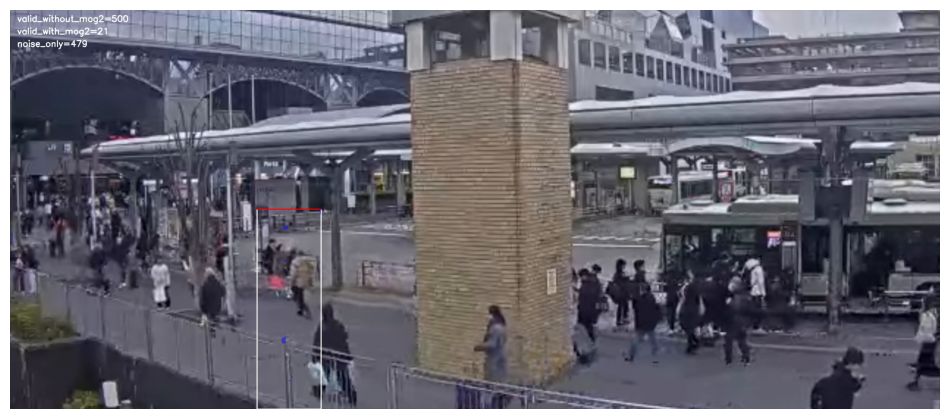

In [15]:
# =========================================================================================
# 6) MOG2=Falseの場合、解析対象に入ってしまう画素（ノイズ）を、1フレームだけ可視化して確認
# =========================================================================================
FRAME_TO_CHECK = 200   # 確認したいフレーム番号
CENTER_RATIO = 0.30    # 人が横断する量を観測する中心線の位置
ZONE_HALF_W = 90       # 中心線からの解析範囲（半径）
Y_LINE_RATIO = 0.50    # Y方向の境界線位置
OBSERVE_BELOW = True   # Y方向の境界線より下側だけを観測対象にする設定

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"動画が開けません: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

crossing_line_x = int(W * CENTER_RATIO)
zone_left = max(0, crossing_line_x - ZONE_HALF_W)
zone_right = min(W, crossing_line_x + ZONE_HALF_W)

y_line = int(H * Y_LINE_RATIO)
if OBSERVE_BELOW:
    y1, y2 = y_line, H
else:
    y1, y2 = 0, y_line

mog2 = cv2.createBackgroundSubtractorMOG2(
    history=MOG2_HISTORY,
    varThreshold=MOG2_VARTHRESH,
    detectShadows=False
)

prev_gray = None    # 前フレームのグレースケール画像
frame_idx = -1      # 現在のフレーム
target_vis = None   # 最終可視化画像

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    # グレースケール化
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is None:
        prev_gray = gray
        mog2.apply(frame, learningRate=MOG2_LR)
        continue

    # MOG2を更新
    fg = mog2.apply(frame, learningRate=MOG2_LR)

    if frame_idx == FRAME_TO_CHECK:
        prev_zone = prev_gray[y1:y2, zone_left:zone_right]
        curr_zone = gray[y1:y2, zone_left:zone_right]

        # オプティカルフローを計算
        flow = cv2.calcOpticalFlowFarneback(
            prev_zone, curr_zone, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )

        # フローを成分に分解
        fx = flow[..., 0]
        fy = flow[..., 1]
        mag = np.sqrt(fx*fx + fy*fy)

        valid_without_mog2 = (mag > 0.2)

        fg_zone = fg[y1:y2, zone_left:zone_right]
        fg_zone = cv2.medianBlur(fg_zone, 5)
        valid_with_mog2 = (fg_zone > 0) & (mag > 0.2)

        # ノイズになった画素
        noise_only = valid_without_mog2 & (~valid_with_mog2)

        vis = frame.copy()

        # 観測帯域
        cv2.rectangle(vis, (zone_left, y1), (zone_right, y2), (255,255,255), 2)
        cv2.line(vis, (zone_left, y_line), (zone_right, y_line), (0,0,255), 2)

        # noise_onlyを赤で塗る
        overlay = vis.copy()
        roi = overlay[y1:y2, zone_left:zone_right]
        roi[noise_only] = (255, 0, 0)
        overlay[y1:y2, zone_left:zone_right] = roi

        # 半透明で重ねる
        vis = cv2.addWeighted(overlay, 0.45, vis, 0.55, 0)

        # 数値表示
        n_false = int(np.sum(valid_without_mog2))
        n_true = int(np.sum(valid_with_mog2))
        n_noise = int(np.sum(noise_only))

        cv2.putText(vis, f"valid_without_mog2={n_false}", (20, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        cv2.putText(vis, f"valid_with_mog2={n_true}", (20, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        cv2.putText(vis, f"noise_only={n_noise}", (20, 105),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

        target_vis = vis
        break

    prev_gray = gray

cap.release()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(target_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [16]:
# ============================================================
# 7) MOG2=Falseで観測されたノイズの割合を定量化
# ============================================================

CENTER_RATIO = 0.30
ZONE_HALF_W = 90
Y_LINE_RATIO = 0.50
OBSERVE_BELOW = True
FRAME_STRIDE = 2

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"動画が開けません: {VIDEO_PATH}")

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

crossing_line_x = int(W * CENTER_RATIO)
zone_left = max(0, crossing_line_x - ZONE_HALF_W)
zone_right = min(W, crossing_line_x + ZONE_HALF_W)

y_line = int(H * Y_LINE_RATIO)
if OBSERVE_BELOW:
    y1, y2 = y_line, H
else:
    y1, y2 = 0, y_line

# MOG2初期化
mog2 = cv2.createBackgroundSubtractorMOG2(
    history=MOG2_HISTORY,
    varThreshold=MOG2_VARTHRESH,
    detectShadows=False
)

prev_gray = None      # 前フレームのグレースケール画像
frame_idx = -1        # 現在のフレーム

sum_valid_without_mog2 = 0   # 全フレームにおけるvalid_without_mog2の画素数合計
sum_valid_with_mog2 = 0    # 全フレームにおけるvalid_with_mog2の画素数合計
sum_noise_only = 0    # 全フレームにおけるnoise_onlyの画素数合計
sum_total_pixels = 0  # 解析対象ROIの総画素数を、全処理フレーム分だけ合計

pbar = tqdm(total=nframes, desc="Quantify noise_only")

# 定量化開始
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1
    pbar.update(1)

    if frame_idx % FRAME_STRIDE != 0:
        continue

    # グレースケール化
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is None:
        prev_gray = gray
        mog2.apply(frame, learningRate=MOG2_LR)
        continue

    # 現フレームでMOG2を更新
    fg = mog2.apply(frame, learningRate=MOG2_LR)

    # ROI内の前後フレームを切り出す
    prev_zone = prev_gray[y1:y2, zone_left:zone_right]
    curr_zone = gray[y1:y2, zone_left:zone_right]

    # オプティカルフローを計算
    flow = cv2.calcOpticalFlowFarneback(
        prev_zone, curr_zone, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )

    # フローの成分と大きさを計算
    fx = flow[..., 0]
    fy = flow[..., 1]
    mag = np.sqrt(fx*fx + fy*fy)

    # MOG2なし場合の有効画素
    valid_without_mog2 = (mag > 0.2)

    # MOG2あり場合 の有効画素
    fg_zone = fg[y1:y2, zone_left:zone_right]
    fg_zone = cv2.medianBlur(fg_zone, 5)
    valid_with_mog2 = (fg_zone > 0) & (mag > 0.2)

    # MOG2なしの場合のノイズ
    noise_only = valid_without_mog2 & (~valid_with_mog2)

    # 各画素数を累積
    sum_valid_without_mog2 += int(np.sum(valid_without_mog2))   # MOG2なしで有効と判定された画素数
    sum_valid_with_mog2 += int(np.sum(valid_with_mog2))         # MOG2ありで有効と判定された画素数
    sum_noise_only += int(np.sum(noise_only))                   # MOG2なしでしか含まれない画素数
    sum_total_pixels += valid_without_mog2.size                 # 全処理フレーム分のROI総画素数

    prev_gray = gray

pbar.close()
cap.release()

result = {
    "valid_without_mog2_ratio": sum_valid_without_mog2 / (sum_total_pixels + 1e-9),     # 観測範囲全体の画素のうち、MOG2なしで有効とされた割合
    "valid_with_mog2_ratio": sum_valid_with_mog2 / (sum_total_pixels + 1e-9),           # 観測範囲全体の画素のうち、MOG2ありで有効とされた割合
    "noise_only_ratio": sum_noise_only / (sum_total_pixels + 1e-9),                     # 観測範囲全体の画素のうち、MOG2なしでしか含まれない画素の割合
    "noise_only_share_in_false": sum_noise_only / (sum_valid_without_mog2 + 1e-9),      # MOG2なしで有効とされた画素のうち、MOG2ありでは観測されないかを表す割合
}

print(result)

Quantify noise_only:   0%|          | 0/3523 [00:00<?, ?it/s]

{'valid_without_mog2_ratio': 0.33432669323874187, 'valid_with_mog2_ratio': 0.08798384576184623, 'noise_only_ratio': 0.24634284747689564, 'noise_only_share_in_false': 0.7368327221810639}


In [17]:
# =====================================
# 8) A方向・B方向の総流量と B/Aを集計
# =====================================
csv_dir = "/content/drive/MyDrive/result_csv/"   # 集計対象のCSVが入っているフォルダ
csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

results = []  # 集計結果格納用のリスト

# CSVファイルを1件ずつ処理
for path in csv_files:
    filename = os.path.basename(path)

    # MOG2=True のファイルだけ処理
    if "mog2=True" not in filename:
        continue

    df = pd.read_csv(path)

    total_A = df["A_flow_sum"].sum()  # A方向総流量を計算
    total_B = df["B_flow_sum"].sum()  # B方向総流量を計算
    BA = total_B / (total_A + 1e-9)   # B/A比を計算

    results.append({
        "file": filename,
        "A_total": total_A,
        "B_total": total_B,
        "BA": BA
    })

df_result_true = pd.DataFrame(results)

display(df_result_true)

if len(df_result_true) > 0:
    print("総A_flow 平均 :", df_result_true["A_total"].mean())
    print("総B_flow 平均 :", df_result_true["B_total"].mean())
    print("平均B/A :", df_result_true["BA"].mean())
    print("最小B/A :", df_result_true["BA"].min())
    print("最大B/A :", df_result_true["BA"].max())
else:
    print("MOG2=True のCSVが見つかりません")

,file,A_total,B_total,BA
0,cr=0.30_hw=60_thr=0.8_mog2=True_stride=2.csv,2.113458e+07,1.951902e+07,0.923558
1,cr=0.30_hw=60_thr=1.0_mog2=True_stride=2.csv,2.098976e+07,1.937528e+07,0.923083
2,cr=0.30_hw=60_thr=1.2_mog2=True_stride=2.csv,2.083897e+07,1.922838e+07,0.922713
3,cr=0.30_hw=90_thr=0.8_mog2=True_stride=2.csv,3.658679e+07,3.515100e+07,0.960757
4,cr=0.30_hw=90_thr=1.0_mog2=True_stride=2.csv,3.638977e+07,3.495104e+07,0.960463
5,cr=0.30_hw=90_thr=1.2_mog2=True_stride=2.csv,3.618834e+07,3.474590e+07,0.960141
6,cr=0.30_hw=120_thr=0.8_mog2=True_stride=2.csv,4.983125e+07,4.931016e+07,0.989543
7,cr=0.30_hw=120_thr=1.0_mog2=True_stride=2.csv,4.957003e+07,4.903865e+07,0.989280
8,cr=0.30_hw=120_thr=1.2_mog2=True_stride=2.csv,4.930427e+07,4.876273e+07,0.989016


総A_flow 平均 : 35648195.23215396
総B_flow 平均 : 34453574.146350555
平均B/A : 0.9576171127116567
最小B/A : 0.9227126950036748
最大B/A : 0.9895428967860723


In [18]:
# =====================================
# 9) 解析動画を再生（可視化説明用）
# =====================================
from IPython.display import Video
import shutil

# Drive → /content
shutil.copy(
"/content/drive/MyDrive/videos/cr=0.30_hw=90_thr=1.0_mog2=True_stride=2.mp4",
"/content/video.mp4"
)

!ffmpeg -y -i /content/video.mp4 -c:v libx264 -pix_fmt yuv420p -movflags +faststart /content/video_fixed.mp4

Video("/content/video_fixed.mp4", embed=True, width=800)

Output hidden; open in https://colab.research.google.com to view.

# **2. 分析レポート**

##**1. 分析の目的**

京都駅前エリアにおける慢性的な混雑について、以下2つの仮説のどちらが主因であるかを、定量的に検証することを目的としました。<br><br>
・仮説A（電車由来）
駅舎から駅前広場へ流出する人流が混雑を引き起こしている

・仮説B（バス由来）
バス停から駅舎へ向かう人流が混雑を引き起こしている<br><br>

本分析では、定点カメラ映像を用いて、両方向の人流量を定量化し比較しました<br><br>

##**2. 分析アプローチの説明**
###2.1 採用した分析手法

本分析では、以下の3段階の手法を採用しました。<br>
####① 観測帯域の設計（中心横断帯域）<br>
仮説A/Bはいずれも「駅舎 ↔ バス停方向の横断移動」に起因するため、画面全体ではなく柱より左の横断帯域に限定して分析しました。

これにより、無関係な背景動きの影響を低減し、仮説と直接関係する人流のみを抽出することができます。<br>

####② オプティカルフローによる方向別流量推定<br>
動画解析技術の1つであり、動画内の物体がどのように動いているかを計算するオプティカルフローを用いて算出しました。

特に「横方向の移動量（fx）」に着目し、

fx > +閾値 → 左→右（仮説A：電車由来）

fx < -閾値 → 右→左（仮説B：バス由来）

として方向別に積算しました。<br>
※閾値とは、動画内で「実際に人が移動した」と判断するための基準値です。

この積算値を 流量指数と定義しました。<br><br>

####③ 不要な動きの除外（ノイズ対策）
カメラ映像には、

・風による揺れ  
・影の変化  
・わずかな明るさの変化  
・カメラの微振動  

など、人の移動とは関係のない小さな変化も含まれます。

そのため本分析では、

1. 「実際に動いている部分」だけを抽出する処理  
2. 横方向の移動量が一定以上の場合のみを有効とする基準  

を組み合わせ、できる限り“人の移動に由来する動き”だけを分析対象としました。

これにより、誤検出やノイズの影響を抑えています。<br><br>

### 2.2 本手法を選定した理由  
なぜ「人物を数える方法」ではなく、「流れを測る方法」を採用したのか？

京都駅前のような混雑環境では、

・人同士が重なって見える  
・柱や看板で一部が隠れる  
・集団でまとまって移動する  

といった状況が頻繁に発生します。

そのため、物体検出AI等で1人ずつ検出して追跡する方法では、

・同じ人を別人として認識してしまう  
・一時的に見えなくなった人を見失う  

といった誤差が生じやすく、安定した比較が難しくなります。

そこで本分析では、「何人いるか」ではなく、
「どちらの方向にどれだけ流れているか」に着目しました。

この方法では、個々の人物を識別せず、
画面全体の動きの傾向をまとめて測るため、

・混雑していても安定して測定できる  
・人の重なりの影響を受けにくい  

という利点があります。

そのため、本課題の目的である
“方向別の混雑原因比較”に適していると判断しました。<br><br>

##**3. 分析結果**
###3.1 10秒単位の流量比較

動画を10秒ごとに区切り、
電車方向（A）とバス方向（B）の流量指数を比較しました。

1例として、以下のような結果が得られました。

| 区間(sec) | A_flow | B_flow | B/A比 | 判定    |
| ------- | ------ | ------ | ---- | ----- |
| 0–10    | 12,540 | 11,230 | 0.89 | Aやや多い |
| 10–20   | 13,120 | 12,840 | 0.98 | ほぼ同程度 |
| 20–30   | 11,980 | 12,110 | 1.01 | ほぼ同程度 |

このように、区間ごとに多少の変動はあるものの、
大きく一方向に偏る傾向は確認されませんでした。<br><br>

###3.2 全体集計結果

動画全体の累積流量を比較すると、次の結果となりました。

| 項目      | 値               |
| ------- | --------------- |
| 総A_flow |  35648195.23            |
| 総B_flow |  34453574.15            |
| B/A比    | 約 **0.96** |
<br>

| B/A比      | 解釈     |
| --------- | ------ |
| B/A > 1.1 | バス方向優勢 |
| B/A < 0.9 | 電車方向優勢 |
| 0.9〜1.1   | ほぼ同程度  |

今回の結果では、B/A ≈ 1.0であり、電車方向とバス方向の人流は概ね同程度であることが確認されました。<br><br>

###3.3 可視化による裏付け

分析結果の妥当性を確認するため、
解析結果を重ねた可視化動画を作成しました。<br>
※9) 解析動画を再生（可視化説明用）で出力された動画を再生してください。

動画では以下を表示しています。

・観測帯域のヒートマップ<br>
・人流方向を示す矢印<br>
・10秒ごとの優勢方向表示<br>

数値で算出された流量と映像上の実際の人の動きが概ね一致していることを確認しました。<br>
この結果から、算出された流量指数は、実際の人流方向を適切に反映していると判断できます。<br><br>

##**4. 分析結果の妥当性担保**

本分析結果が偶然の結果や、特定の設定に依存した結果ではないことを確認するため、以下の観点から検証を行いました。<br><br>

### 4.1 ノイズ影響の検証
分析アプローチで説明したように、映像には人の移動以外にも、以下のような変化が含まれます。<br>
・影の変化<br>
・照明の変化<br>
・カメラの微振動<br>
・背景の揺れ<br>
これらの分析に不要な要素を除去するため、本分析では、背景差分処理を用いて「実際に動いている領域のみ」を抽出しました。

背景差分を使用した場合と使用しない場合を比較すると、
次の結果となりました。<br>
| 指標       | 背景差分あり     | 背景差分なし      |
| -------- | ---------- | ----------- |
| 動き検出画素割合 | 約 **8.8%** | 約 **33.4%** |<br>

ノイズ除去を行わない場合、動きとして検出される画素は約4倍に増加しました。
さらに、
背景差分なしで検出された動きの約74%は、背景差分を適用すると除外されることが確認されました。これは、影、照明変化、カメラ揺れなどの背景変動を動きとして誤検出している可能性を示します。<br>
そのため本分析では、
背景差分を用いた結果を主解析として採用しました。<br><br>

### 4.2 パラメータ依存性の確認

分析結果が特定の設定に依存していないことを確認するため、<br>
・観測帯域の幅<br>
・移動判定の閾値<br>
・ノイズ処理の有無<br>
を変更した 計18通りの条件で分析を実施しました。

その結果、背景差分を適用した条件では<br>
**B/A ≈ 0.92〜0.99**<br>
の範囲に収まり、
設定を変更しても結論が大きく変化しないことが確認されました。<br>
これにより、本分析結果は、特定パラメータに依存しない安定した結果であると判断できます。<br><br>

### 4.3 時系列安定性の確認
横方向移動の判定閾値を変更した場合でも、方向優勢の傾向が大きく変化しないことを確認しました。

これにより、結論が特定パラメータに過度に依存していないことを担保しています。<br><br>
### 4. 時系列安定性の確認
瞬間的な動きに影響されないよう、人流は 10秒単位で集計しました。
このことから、一時的な人の通過、単発的なピークによる誤判定を避け、一定時間継続する人流傾向として評価しています。<br><br>

##**5. 分析手法の限界**

本手法には以下の制約があります。

① 個人数は直接カウントしていない

流量指数は「移動強度の総和」であり、実人数とは完全一致しない。

② カメラ視点依存

俯瞰角度・遠近歪みの影響を受ける。

③ 滞留混雑は直接評価できない

立ち止まり滞在はフロー解析では検出困難。<br><br>

##**6. 仮説の検証結果（結論）**

動画全体の流量比較では、**B/A比 ≈ 1.0**となり、電車方向とバス方向の人流は概ね同程度でした。

そのため本動画区間では、**混雑の主因が電車またはバスのどちらか一方である**
という明確な証拠は確認されませんでした。

むしろ、<br>

・電車利用者<br>
・バス利用者<br>

の双方の流入が混雑に影響している可能性が高いと考えられます。<br><br>

##**7. 施策提案に向けた考察**

本分析は方向別流量比較に焦点を当てましたが、実際の施策立案には以下の追加分析が有効と考えられます。

###**7.1 必要な追加データ**

・その他駅前カメラの動画<br>
・電車到着ダイヤ<br>
・バス到着時刻<br>
・時間帯別利用者数<br>
・日時情報<br>
・観光客数<br>
・天候情報<br>

これらを組み合わせることで、混雑発生の要因をより詳細に分析することが可能になります。<br><br>
###**7.2 追加分析案**
**① 到着イベント連動分析**<br>
電車やバスの到着直後に人流が増加するかを確認する。<br>

**② 滞留ヒートマップ分析**<br>
人の滞留が多い場所を特定し、混雑の発生地点を把握する。<br>

**③ 人数推定モデル導入**<br>
物体検出AIを用いた人数推定技術を確立し、流量指数との関係を検証する。<br><br>

##**8. 総括**
本分析では、定点カメラ映像から方向別流量を定量化することで、<br>

仮説A（電車由来）<br>
仮説B（バス由来）<br>

のどちらが優勢かを客観的に判断可能であることを示しました。

本手法は再現性が高く、追加データと組み合わせることで、混雑予測・動線最適化施策へと発展可能と考えられます。